<a href="https://colab.research.google.com/github/Gabriel-Arsego/Garsego_64061/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Imports

In [7]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import os

Loading same data as the example exercise

In [8]:
# Download ZIP
zip_path = keras.utils.get_file(
    origin="https://storage.googleapis.com/tensorflow/tf-keras-datasets/jena_climate_2009_2016.csv.zip",
    extract=True
)

# Find extracted CSV
base_dir = os.path.dirname(zip_path)

csv_path = None
for root, dirs, files in os.walk(base_dir):
    for file in files:
        if file.endswith(".csv"):
            csv_path = os.path.join(root, file)

print("CSV found at:", csv_path)

# Load dataset
df = pd.read_csv(csv_path)
df.head()

CSV found at: /root/.keras/datasets/jena_climate_2009_2016.csv.zip/jena_climate_2009_2016.csv


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [9]:
data = df.values[:, 1:].astype("float32")

mean = data[:200000].mean(axis=0)
std = data[:200000].std(axis=0)

data -= mean
data /= std

sampling_rate = 6
sequence_length = 120
delay = 96  # 48 hours ahead
batch_size = 256

In [10]:
train_dataset = keras.utils.timeseries_dataset_from_array(
    data[:-delay],
    targets=data[delay:, 1],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=True,
    batch_size=batch_size,
    start_index=0,
    end_index=200000
)

val_dataset = keras.utils.timeseries_dataset_from_array(
    data[:-delay],
    targets=data[delay:, 1],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=200001,
    end_index=300000
)

test_dataset = keras.utils.timeseries_dataset_from_array(
    data[:-delay],
    targets=data[delay:, 1],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    shuffle=False,
    batch_size=batch_size,
    start_index=300001
)

In [11]:
def build_dense():
    inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
    x = layers.Flatten()(inputs)
    x = layers.Dense(32, activation="relu")(x)
    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

In [12]:
def build_gru():
    inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
    x = layers.GRU(32)(inputs)
    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

In [13]:
def build_lstm():
    inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
    x = layers.LSTM(32)(inputs)
    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

In [14]:
def build_stacked_gru():
    inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
    x = layers.GRU(32, return_sequences=True)(inputs)
    x = layers.GRU(32)(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

In [15]:
def build_cnn_gru():
    inputs = keras.Input(shape=(sequence_length, data.shape[-1]))
    x = layers.Conv1D(32, 5, activation="relu")(inputs)
    x = layers.MaxPooling1D(3)(x)
    x = layers.GRU(32)(x)
    outputs = layers.Dense(1)(x)
    model = keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mse", metrics=["mae"])
    return model

In [16]:
results = {}
histories = {}

def run_experiment(name, model_fn):
    print(f"\nRunning: {name}")
    model = model_fn()

    history = model.fit(
        train_dataset,
        epochs=10,
        validation_data=val_dataset,
        verbose=1
    )

    val_mae = history.history["val_mae"][-1]

    test_loss, test_mae = model.evaluate(test_dataset)

    results[name] = {
        "val_mae": val_mae,
        "test_mae": test_mae
    }

    return history

In [17]:
histories["Dense"] = run_experiment("Dense", build_dense)
histories["GRU"] = run_experiment("GRU", build_gru)
histories["LSTM"] = run_experiment("LSTM", build_lstm)
histories["Stacked_GRU"] = run_experiment("Stacked_GRU", build_stacked_gru)
histories["CNN_GRU"] = run_experiment("CNN_GRU", build_cnn_gru)


Running: Dense
Epoch 1/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 41s 51ms/step - loss: 0.0655 - mae: 0.1541 - val_loss: 0.0090 - val_mae: 0.0715
Epoch 2/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - loss: 0.0183 - mae: 0.0769 - val_loss: 0.0050 - val_mae: 0.0546
Epoch 3/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - loss: 0.0047 - mae: 0.0500 - val_loss: 0.0040 - val_mae: 0.0476
Epoch 4/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 39s 50ms/step - loss: 0.0094 - mae: 0.0534 - val_loss: 0.0020 - val_mae: 0.0328
Epoch 5/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 38s 49ms/step - loss: 0.0075 - mae: 0.0535 - val_loss: 0.0032 - val_mae: 0.0441
Epoch 6/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - loss: 0.0063 - mae: 0.0442 - val_loss: 0.0013 - val_mae: 0.0264
Epoch 7/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 37s 47ms/step - loss: 0.0030 - mae: 0.0368 - val_loss: 0.0033 - val_mae: 0.0424
Epoch 8/10
779/779 ━━━━━━━━━━━━━━━━━━━━ 37s 48ms/step - loss: 0.0054 - mae: 0.0418 - val_loss: 0.0012 - val_mae: 0.0263
Epoch 9/10
779/779 ━━━━━

In [18]:
results_df = pd.DataFrame(results).T
print(results_df)

              val_mae  test_mae
Dense        0.040105  0.205593
GRU          0.009407  0.013938
LSTM         0.051153  0.057572
Stacked_GRU  0.034721  0.036551
CNN_GRU      0.016959  0.019572


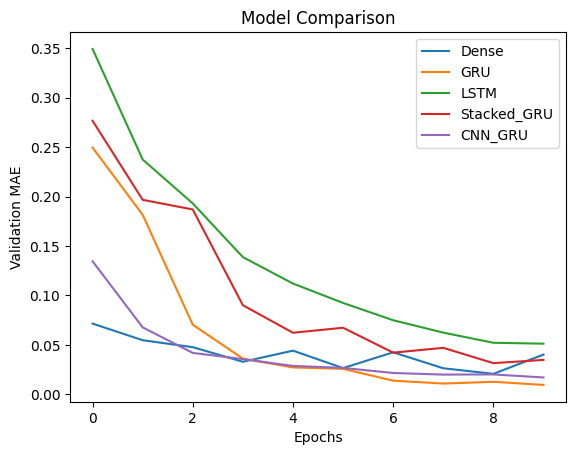

In [19]:
for name, history in histories.items():
    plt.plot(history.history["val_mae"], label=name)

plt.xlabel("Epochs")
plt.ylabel("Validation MAE")
plt.title("Model Comparison")
plt.legend()
plt.show()